# **Task: Create a Backup of Project Files**

# During the previous tasks, our Python application created several files:

# project/
# │
# ├── students.csv
# ├── students.json
# └── student_report.xlsx

# We need to create a ZIP archive containing the project files.

# During this task, we will:

# Create a ZIP archive.
# Add several files to the archive.
# View the contents of an existing archive.
# Extract one file.
# Extract all files.
# Create a backup of an entire directory.

# **Step 1. Import the zipfile module**

# Python provides the built-in zipfile module:

In [1]:
import zipfile

# **Step 2. Create a ZIP archive**

In [2]:
with zipfile.ZipFile("project_backup.zip", "w") as archive:
    archive.write("file3.csv")
    archive.write("file2.jpg")
    archive.write("file1.xlsx")

# **Step 3. Use compression**

In [3]:
with zipfile.ZipFile("project_backup1.zip","w",
                     compression=zipfile.ZIP_DEFLATED) as archive:

    archive.write("file3.csv")
    archive.write("file2.jpg")
    archive.write("file1.xlsx")

# Available Algorithms:
# ZIP_STORED — no compression
# ZIP_DEFLATED — standard DEFLATE algorithm (need zlib)
# ZIP_BZIP2 — bzip2 compression
# ZIP_LZMA — LZMA compression

# **Step 4. Add a new file to an existing archive**

In [8]:
with zipfile.ZipFile(
    "project_backup1.zip",
    "a",
    compression=zipfile.ZIP_DEFLATED
) as archive:

    archive.write("students.json")

# **Step 5. Open and read an existing ZIP archive**
# Open project_backup.zip and display all files stored inside.

In [9]:
with zipfile.ZipFile("project_backup1.zip", "r") as archive:
    files = archive.namelist()
    print(files)

['file3.csv', 'file2.jpg', 'file1.xlsx', 'file4.txt', 'students.json']


# **Step 6. Get information about archived files**

In [6]:
with zipfile.ZipFile("project_backup1.zip", "r") as archive:
    for file in archive.infolist():
        print("Name:", file.filename)
        print("Original size:", file.file_size)
        print("Compressed size:", file.compress_size)
        print()

Name: file3.csv
Original size: 452
Compressed size: 245

Name: file2.jpg
Original size: 2629153
Compressed size: 2623314

Name: file1.xlsx
Original size: 13089
Compressed size: 7744

Name: file4.txt
Original size: 20
Compressed size: 22



# **Why can a compressed file be larger than the original file?**
# Compression does not always make a file smaller. For very small files, the compressed size can be slightly larger because compression requires additional metadata. Compression is more effective for larger files with repetitive data.

# **Step 7. Extract one file**

In [10]:
with zipfile.ZipFile("project_backup1.zip", "r") as archive:

    archive.extract(
        "students.json",
        "extracted"
    )

# **Step 8. Extract all files**

In [11]:
with zipfile.ZipFile("project_backup1.zip", "r") as archive:

    archive.extractall("restored_project")

# **Step 9. Archive files from a directory**

In [13]:
import os
import zipfile

with zipfile.ZipFile("project_backup1.zip", "w",
    compression=zipfile.ZIP_DEFLATED) as archive:

    for root, directories, files in os.walk("restored_project"):
        for file in files:
            file_path = os.path.join(root, file)
            archive.write(file_path)
            print("Added:", file_path)
            print(root)

Added: restored_project\file1.xlsx
restored_project
Added: restored_project\file2.jpg
restored_project
Added: restored_project\file3.csv
restored_project
Added: restored_project\file4.txt
restored_project
Added: restored_project\students.json
restored_project


# **Step 10. Preserve the project directory structure**

# Но предыдущий вариант может сохранить внутри ZIP пути не совсем так, как нам хочется.

# Лучше использовать arcname.

In [14]:
import os
import zipfile

project_folder = "restored_project"

with zipfile.ZipFile("project_backup1.zip",    "w",
    compression=zipfile.ZIP_DEFLATED) as archive:

    for root, directories, files in os.walk(project_folder):
        for file in files:
            file_path = os.path.join(root, file)
            archive_name = os.path.relpath(
                file_path,
                project_folder
            )
            archive.write(
                file_path,
                arcname=archive_name
            )

# **Step 11. Check whether a file exists in the archive**
# Check whether students.json exists in the backup.

In [17]:
with zipfile.ZipFile("project_backup1.zip", "r") as archive:

    files = archive.namelist()
    if "file1.xlsx" in files:
        print("file1.xlsx found")
    else:
        print("file1.xlsx not found")

file1.xls found


# **Module tarfile**

# Python provides the built-in tarfile module for creating, reading, and extracting TAR archives.

# A TAR archive combines multiple files and directories into a single archive.

In [18]:
import tarfile

# TAR primarily combines multiple files into a single archive, while compression is usually added separately, for example using GZIP.

# **Step 1. Create a TAR archive**

In [19]:
with tarfile.open("project_backup2.tar", "w") as archive:
    archive.add(
        "restored_project",
        arcname="restored_project"
    )

print("TAR archive created.")

TAR archive created.


# **Step 2. Create a compressed .tar.gz archive**

In [20]:
with tarfile.open("project_backup3.tar.gz", "w:gz") as archive:
    archive.add(
        "restored_project",
        arcname="restored_project"
    )

print("Compressed TAR archive created.")

Compressed TAR archive created.


# **Step 3. Open an existing TAR archive**

In [21]:
with tarfile.open("project_backup3.tar.gz", "r:gz") as archive:
    print(archive.getnames())

['restored_project', 'restored_project/file1.xlsx', 'restored_project/file2.jpg', 'restored_project/file3.csv', 'restored_project/file4.txt']


# **Step 4. Get information about archived files**

In [22]:
with tarfile.open("project_backup3.tar.gz", "r:gz") as archive:

    for member in archive.getmembers():

        print("Name:", member.name)
        print("Size:", member.size)
        print("File:", member.isfile())
        print("Directory:", member.isdir())
        print()

Name: restored_project
Size: 0
File: False
Directory: True

Name: restored_project/file1.xlsx
Size: 13089
File: True
Directory: False

Name: restored_project/file2.jpg
Size: 3255320
File: True
Directory: False

Name: restored_project/file3.csv
Size: 452
File: True
Directory: False

Name: restored_project/file4.txt
Size: 20
File: True
Directory: False



# **Step 5. Extract one file**

In [24]:
with tarfile.open("project_backup3.tar.gz", "r:gz") as archive:

    member = archive.getmember(
        "restored_project/file1.xlsx"
    )

    archive.extract(
        member,
        path="extracted"
    )

/tmp/ipykernel_3673/3649950849.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extract(


# **Step 6. Extract all files**

In [25]:
with tarfile.open("project_backup3.tar.gz", "r:gz") as archive:

    archive.extractall(
        path="restored_project1"
    )

/tmp/ipykernel_3673/1389369759.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(


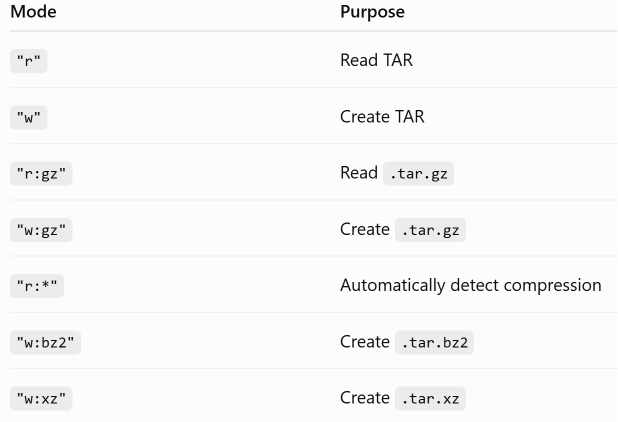

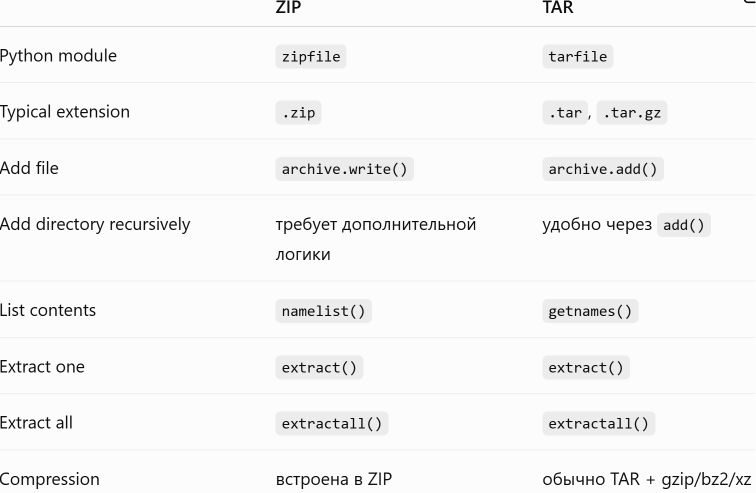

# **В чём отличие TAR от ZIP? **
# ZIP = упаковка + сжатие каждого файла отдельно.
# TAR = упаковка всех файлов в один контейнер → потом общий архив сжимается целиком (gzip, bzip2 и т.д.).
# Поэтому .tar.gz часто компактнее, чем .zip, и быстрее в распаковке на Linux/Unix.